<a href="https://colab.research.google.com/github/tcano0505/Financial_Anomaly_Models/blob/main/Financial_Anomaly_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install yfinance langchain_pinecone openai python-dotenv langchain_community sentence_transformers

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
from langchain_pinecone import PineconeVectorStore
from openai import OpenAI
import dotenv
import json
import yfinance as yf
import concurrent.futures
from langchain_community.embeddings import HuggingFaceEmbeddings
from google.colab import userdata
from langchain.schema import Document
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from pinecone import Pinecone
import numpy as np
import requests
import os

In [ ]:
df = pd.read_csv('EWS.csv')

In [ ]:
df

,Y,Data,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,...,LP01TREU,EMUSTRUU,LF94TRUU,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN
0,0,1/11/2000,283.25,0.077,1388.0,157.2600,100.560,105.86,1.6460,25.77,...,116.4640,230.527,123.7620,1416.12,127.75,990.59,856.76,224.33,217.34,34.30
1,0,1/18/2000,287.65,0.043,1405.0,165.0100,101.860,105.47,1.6380,28.85,...,117.2670,231.377,123.7620,1428.79,129.50,993.98,925.22,234.37,227.08,32.74
2,0,1/25/2000,287.15,0.135,1368.0,167.2400,102.410,106.04,1.6500,28.28,...,117.9950,232.390,123.7620,1385.93,126.48,974.83,886.93,216.82,233.00,32.46
3,0,2/1/2000,282.75,0.191,1311.0,166.8500,104.920,107.85,1.6110,28.22,...,120.5100,231.942,122.3280,1385.31,129.19,1007.12,842.60,201.89,237.48,31.29
4,1,2/8/2000,298.40,0.312,1277.0,165.4300,104.220,109.30,1.6110,28.02,...,118.7910,237.812,122.3280,1411.95,134.67,1034.58,945.15,218.00,258.02,31.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,3/23/2021,1727.96,0.339,2271.0,184.5022,92.336,108.72,1.3760,57.76,...,427.7972,1249.403,389.8500,3800.77,140.32,1199.57,1671.73,681.21,1695.96,110.83
1107,0,3/30/2021,1685.56,0.303,2103.0,184.8741,93.297,110.29,1.3719,60.55,...,428.6578,1242.264,385.8145,3835.96,142.76,1206.29,1635.57,693.38,1690.76,108.80
1108,0,4/6/2021,1743.28,0.440,2092.0,185.8393,92.335,109.88,1.3822,59.33,...,430.6649,1250.256,390.6819,3955.16,144.13,1194.62,1689.62,673.20,1689.48,111.92
1109,0,4/13/2021,1742.69,0.467,2140.0,188.1368,91.852,109.19,1.3737,60.18,...,430.4087,1252.563,390.3848,4027.05,144.23,1197.06,1680.82,680.23,1672.46,108.40


In [ ]:
df.describe()

,Y,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,VIX,...,LP01TREU,EMUSTRUU,LF94TRUU,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN
count,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,...,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000
mean,0.213321,987.463744,0.036153,2259.860486,245.247670,90.934982,106.605734,1.569661,60.708101,19.992169,...,232.109985,704.379545,259.052717,1606.997102,107.877138,784.846292,1903.216436,648.681377,693.156616,53.933159
std,0.409837,494.623740,0.349453,2017.811888,68.278066,11.379095,12.840754,0.212344,25.900813,8.642157,...,109.917628,309.951757,75.934451,698.481956,20.795973,200.076443,986.468254,299.096020,405.527014,24.738356
min,0.000000,256.680000,-0.974000,291.000000,106.293000,71.329000,75.940000,1.172000,10.010000,9.430000,...,80.797000,230.527000,121.331000,663.690000,56.300000,431.710000,280.500000,151.250000,112.600000,13.460000
25%,0.000000,433.740000,-0.191000,990.000000,184.705550,81.240500,101.565000,1.418000,39.625000,13.640000,...,131.025000,434.661000,205.315500,1103.925000,90.605000,601.615000,1042.645000,463.195000,278.385000,28.565000
50%,0.000000,1137.800000,0.035000,1518.000000,234.560000,89.716000,108.720000,1.562000,57.400000,17.980000,...,213.205000,714.807000,264.770000,1324.430000,111.320000,786.830000,1860.960000,612.930000,691.530000,58.740000
75%,0.000000,1324.825000,0.260500,2685.500000,301.539500,97.404000,116.220000,1.677500,79.640000,23.625000,...,342.884500,939.824500,320.753000,1992.445000,126.470000,965.875000,2533.770000,793.620000,1014.750000,68.460000
max,1.000000,2006.910000,0.991000,11793.000000,467.570000,119.820000,134.630000,2.085000,140.970000,75.910000,...,431.552800,1286.353000,398.706500,4043.690000,146.390000,1210.580000,4721.360000,1617.640000,1730.510000,129.200000


In [ ]:
features = df.drop('Y', axis = 1)

### Refining the Data

In [ ]:
features

,Data,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,VIX,...,LP01TREU,EMUSTRUU,LF94TRUU,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN
0,1/11/2000,283.25,0.077,1388.0,157.2600,100.560,105.86,1.6460,25.77,22.50,...,116.4640,230.527,123.7620,1416.12,127.75,990.59,856.76,224.33,217.34,34.30
1,1/18/2000,287.65,0.043,1405.0,165.0100,101.860,105.47,1.6380,28.85,21.50,...,117.2670,231.377,123.7620,1428.79,129.50,993.98,925.22,234.37,227.08,32.74
2,1/25/2000,287.15,0.135,1368.0,167.2400,102.410,106.04,1.6500,28.28,23.02,...,117.9950,232.390,123.7620,1385.93,126.48,974.83,886.93,216.82,233.00,32.46
3,2/1/2000,282.75,0.191,1311.0,166.8500,104.920,107.85,1.6110,28.22,23.45,...,120.5100,231.942,122.3280,1385.31,129.19,1007.12,842.60,201.89,237.48,31.29
4,2/8/2000,298.40,0.312,1277.0,165.4300,104.220,109.30,1.6110,28.02,21.25,...,118.7910,237.812,122.3280,1411.95,134.67,1034.58,945.15,218.00,258.02,31.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,3/23/2021,1727.96,0.339,2271.0,184.5022,92.336,108.72,1.3760,57.76,20.30,...,427.7972,1249.403,389.8500,3800.77,140.32,1199.57,1671.73,681.21,1695.96,110.83
1107,3/30/2021,1685.56,0.303,2103.0,184.8741,93.297,110.29,1.3719,60.55,19.61,...,428.6578,1242.264,385.8145,3835.96,142.76,1206.29,1635.57,693.38,1690.76,108.80
1108,4/6/2021,1743.28,0.440,2092.0,185.8393,92.335,109.88,1.3822,59.33,18.12,...,430.6649,1250.256,390.6819,3955.16,144.13,1194.62,1689.62,673.20,1689.48,111.92
1109,4/13/2021,1742.69,0.467,2140.0,188.1368,91.852,109.19,1.3737,60.18,16.65,...,430.4087,1252.563,390.3848,4027.05,144.23,1197.06,1680.82,680.23,1672.46,108.40


In [ ]:
features.sample(10)

,Data,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,VIX,...,LP01TREU,EMUSTRUU,LF94TRUU,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN
361,12/12/2006,627.81,-0.650,4270.0,310.830,82.940,117.09,1.965,61.02,10.65,...,161.671,529.514,225.404,1331.67,125.45,1028.45,2106.77,1220.14,523.90,46.45
649,6/19/2012,1619.25,-0.382,954.0,277.210,81.378,78.92,1.573,84.03,18.38,...,240.617,820.702,303.367,1295.17,85.83,451.64,2627.12,729.81,654.14,54.76
2,1/25/2000,287.15,0.135,1368.0,167.240,102.410,106.04,1.650,28.28,23.02,...,117.995,232.390,123.762,1385.93,126.48,974.83,886.93,216.82,233.00,32.46
1001,3/19/2019,1307.61,-0.406,712.0,185.236,96.383,111.37,1.327,59.03,13.56,...,388.460,1120.339,341.601,2700.29,129.74,966.13,2242.48,649.94,1329.39,84.90
641,4/24/2012,1641.39,0.099,1116.0,301.290,79.225,81.17,1.613,103.55,18.10,...,241.073,816.214,303.656,1311.66,87.91,494.48,3004.20,833.93,673.79,58.94
688,3/19/2013,1612.67,0.439,912.0,293.135,82.989,94.93,1.510,92.16,14.39,...,282.104,896.627,314.222,1478.71,101.54,646.69,2712.32,789.23,743.19,59.30
789,2/24/2015,1196.52,-0.285,516.0,222.255,94.493,118.90,1.546,49.28,13.69,...,340.287,922.525,317.981,2023.64,131.83,929.68,1767.80,486.39,1083.88,69.30
1039,12/10/2019,1463.27,0.107,1528.0,182.167,97.413,108.74,1.318,59.24,15.68,...,410.301,1194.427,355.102,2983.78,136.12,1035.95,2217.49,760.65,1332.13,80.33
711,8/27/2013,1419.64,-0.014,1169.0,294.709,81.166,97.24,1.554,109.01,16.77,...,289.362,841.845,303.792,1559.69,102.31,701.12,2069.57,718.24,699.35,58.55
965,7/10/2018,1254.50,0.252,1555.0,198.293,94.158,111.27,1.325,74.11,12.64,...,379.697,1064.628,338.825,2666.24,130.30,1020.72,1695.23,637.86,1273.11,86.56


In [ ]:
selected_columns = ['DXY', 'CRY', 'XAU BGNL', 'VIX', 'BDIY', 'MXUS', 'USGG30YR']
subset_data = features[selected_columns]

In [ ]:
correlation_matrix = subset_data.corr()

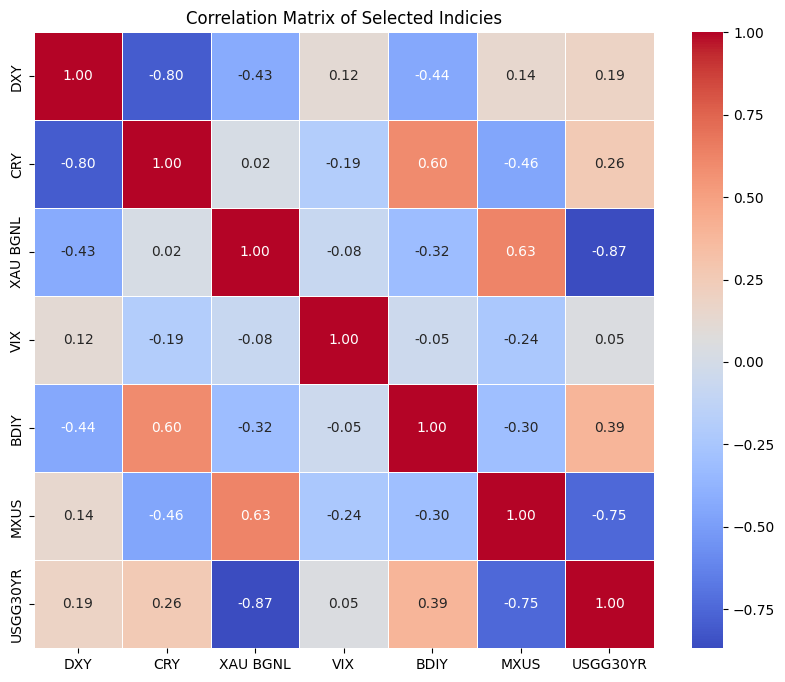

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt = ".2f", cmap='coolwarm', linewidths=0.5, xticklabels=selected_columns, yticklabels=selected_columns)
plt.title('Correlation Matrix of Selected Indicies')
plt.show()

In [ ]:
features = features[selected_columns]
features

,DXY,CRY,XAU BGNL,VIX,BDIY,MXUS,USGG30YR
0,100.560,157.2600,283.25,22.50,1388.0,1416.12,6.6710
1,101.860,165.0100,287.65,21.50,1405.0,1428.79,6.7470
2,102.410,167.2400,287.15,23.02,1368.0,1385.93,6.6340
3,104.920,166.8500,282.75,23.45,1311.0,1385.31,6.4230
4,104.220,165.4300,298.40,21.25,1277.0,1411.95,6.2310
...,...,...,...,...,...,...,...
1106,92.336,184.5022,1727.96,20.30,2271.0,3800.77,2.3264
1107,93.297,184.8741,1685.56,19.61,2103.0,3835.96,2.3687
1108,92.335,185.8393,1743.28,18.12,2092.0,3955.16,2.3230
1109,91.852,188.1368,1742.69,16.65,2140.0,4027.05,2.2939


### Model Creations

Logistic Regression Model
Accuracy: 0.8609865470852018
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       177
           1       0.68      0.61      0.64        46

    accuracy                           0.86       223
   macro avg       0.79      0.77      0.78       223
weighted avg       0.86      0.86      0.86       223



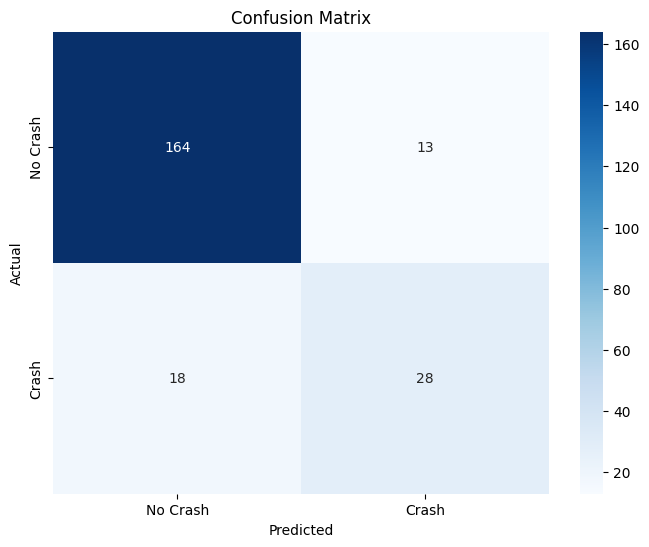

In [ ]:
#Logistic Regression Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the data
X = features
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a Logistic Regression model (you can experiment with other models like RandomForest, SVM, or Neural Networks)
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Model")
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Crash', 'Crash'], yticklabels=['No Crash', 'Crash'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
#Neural Network Model
from sklearn.neural_network import MLPClassifier
nn_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42) #Example structure
nn_model.fit(X_train, y_train)
nn_y_pred = nn_model.predict(X_test)
print(f"Neural Network Accuracy: {accuracy_score(y_test, nn_y_pred)}")
print(classification_report(y_test, nn_y_pred))

Neural Network Accuracy: 0.8565022421524664
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       177
           1       0.68      0.57      0.62        46

    accuracy                           0.86       223
   macro avg       0.79      0.75      0.77       223
weighted avg       0.85      0.86      0.85       223



Random Forest Accuracy: 0.9013452914798207
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       177
           1       0.80      0.70      0.74        46

    accuracy                           0.90       223
   macro avg       0.86      0.83      0.84       223
weighted avg       0.90      0.90      0.90       223



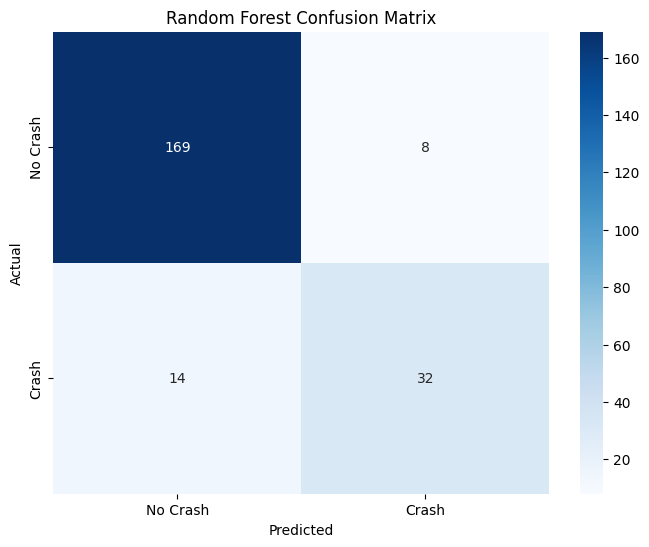

In [ ]:
# RandomForrestClassifier

from sklearn.ensemble import RandomForestClassifier

# Train a RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_y_pred = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print(f"Random Forest Accuracy: {rf_accuracy}")
print(classification_report(y_test, rf_y_pred))

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Crash', 'Crash'], yticklabels=['No Crash', 'Crash'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

SVM Accuracy: 0.8654708520179372
              precision    recall  f1-score   support

           0       0.88      0.95      0.92       177
           1       0.75      0.52      0.62        46

    accuracy                           0.87       223
   macro avg       0.82      0.74      0.77       223
weighted avg       0.86      0.87      0.86       223



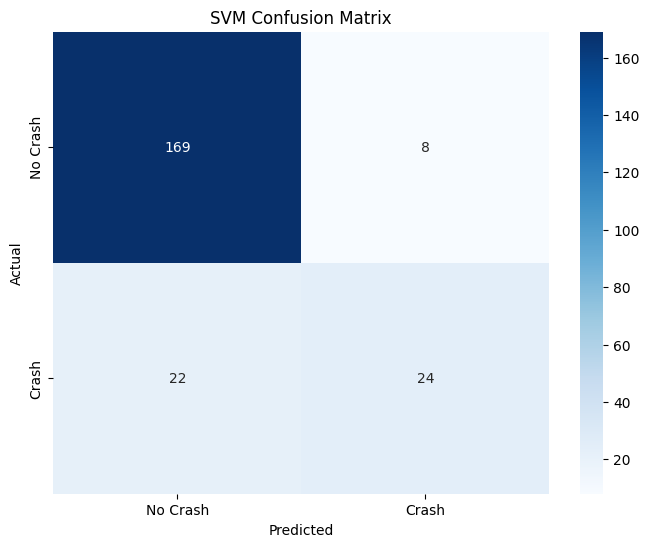

In [ ]:
#Support Vector Machines Model
from sklearn.svm import SVC

# Initialize and train the SVM model
svm_model = SVC(kernel='linear', C=1, random_state=42) # You can experiment with different kernels and C values
svm_model.fit(X_train, y_train)

# Make predictions
svm_y_pred = svm_model.predict(X_test)

# Evaluate the model
svm_accuracy = accuracy_score(y_test, svm_y_pred)
print(f"SVM Accuracy: {svm_accuracy}")
print(classification_report(y_test, svm_y_pred))

# Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Crash', 'Crash'], yticklabels=['No Crash', 'Crash'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

XGBoost Accuracy: 0.8923766816143498
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       177
           1       0.76      0.70      0.73        46

    accuracy                           0.89       223
   macro avg       0.84      0.82      0.83       223
weighted avg       0.89      0.89      0.89       223



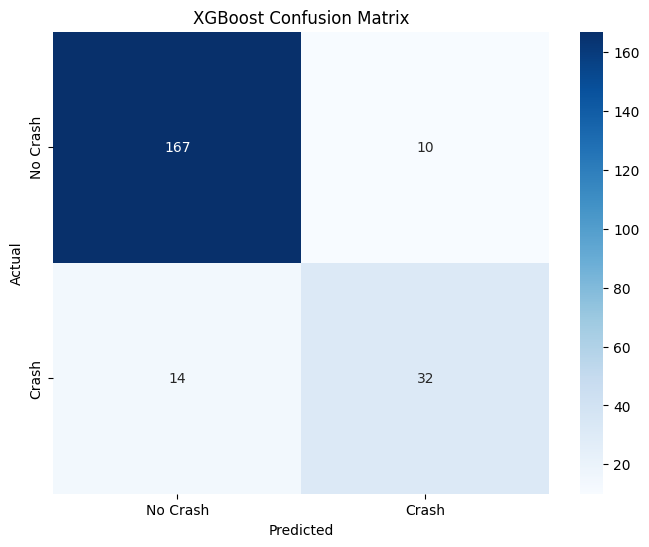

In [ ]:
#XGBoost Model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data
X = features
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the XGBoost model
xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42) # Use binary:logistic for binary classification
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_y_pred = xgb_model.predict(X_test)

# Evaluate the model
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
print(f"XGBoost Accuracy: {xgb_accuracy}")
print(classification_report(y_test, xgb_y_pred))

# Confusion Matrix
xgb_cm = confusion_matrix(y_test, xgb_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Crash', 'Crash'], yticklabels=['No Crash', 'Crash'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

### Compare and Evaluate Models

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_stats = {
    "Logistic Regression": {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred)
    },
    "Neural Network": {
        "accuracy": accuracy_score(y_test, nn_y_pred),
        "precision": precision_score(y_test, nn_y_pred),
        "recall": recall_score(y_test, nn_y_pred),
        "f1": f1_score(y_test, nn_y_pred),
        "classification_report": classification_report(y_test, nn_y_pred)
    },
    "Random Forest": {
        "accuracy": accuracy_score(y_test, rf_y_pred),
        "precision": precision_score(y_test, rf_y_pred),
        "recall": recall_score(y_test, rf_y_pred),
        "f1": f1_score(y_test, rf_y_pred),
        "classification_report": classification_report(y_test, rf_y_pred)
    },
    "SVM": {
        "accuracy": accuracy_score(y_test, svm_y_pred),
        "precision": precision_score(y_test, svm_y_pred),
        "recall": recall_score(y_test, svm_y_pred),
        "f1": f1_score(y_test, svm_y_pred),
        "classification_report": classification_report(y_test, svm_y_pred)
    },
    "XGBoost": {
        "accuracy": accuracy_score(y_test, xgb_y_pred),
        "precision": precision_score(y_test, xgb_y_pred),
        "recall": recall_score(y_test, xgb_y_pred),
        "f1": f1_score(y_test, xgb_y_pred),
        "classification_report": classification_report(y_test, xgb_y_pred)
    }
}


for model_name, metrics in model_stats.items():
    print(f"--- {model_name} ---")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1-score: {metrics['f1']:.4f}")
    print("Classification Report:\n", metrics["classification_report"])
    print("---")

--- Logistic Regression ---
Accuracy: 0.8610
Precision: 0.6829
Recall: 0.6087
F1-score: 0.6437
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91       177
           1       0.68      0.61      0.64        46

    accuracy                           0.86       223
   macro avg       0.79      0.77      0.78       223
weighted avg       0.86      0.86      0.86       223

---
--- Neural Network ---
Accuracy: 0.8565
Precision: 0.6842
Recall: 0.5652
F1-score: 0.6190
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91       177
           1       0.68      0.57      0.62        46

    accuracy                           0.86       223
   macro avg       0.79      0.75      0.77       223
weighted avg       0.85      0.86      0.85       223

---
--- Random Forest ---
Accuracy: 0.9013
Precision: 0.8000
Recall: 0.6957
F1-score: 0.7442
Classification R

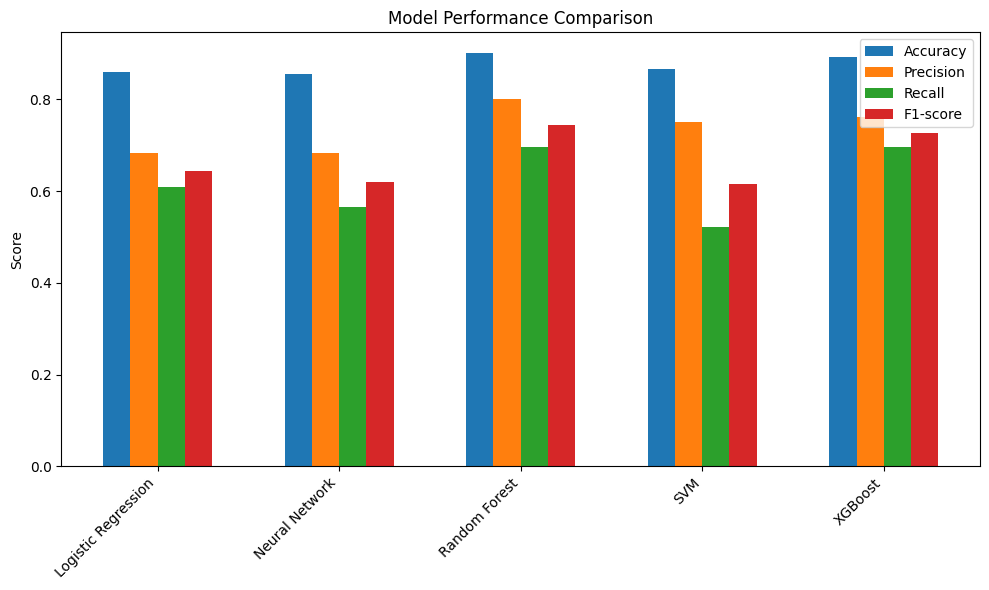

In [ ]:
#bar graphs comparing the accuracies of each metrics of each model

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model_names = list(model_stats.keys())
accuracy = [model_stats[model]['accuracy'] for model in model_names]
precision = [model_stats[model]['precision'] for model in model_names]
recall = [model_stats[model]['recall'] for model in model_names]
f1 = [model_stats[model]['f1'] for model in model_names]

x = range(len(model_names))

fig, ax = plt.subplots(figsize=(10, 6))

width = 0.15
ax.bar([i - 1.5 * width for i in x], accuracy, width, label='Accuracy')
ax.bar([i - 0.5 * width for i in x], precision, width, label='Precision')
ax.bar([i + 0.5 * width for i in x], recall, width, label='Recall')
ax.bar([i + 1.5 * width for i in x], f1, width, label='F1-score')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
plt.tight_layout()
plt.show()